In [9]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, ViTModel
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
# ---------------------------------------------------
# 1. Load pretrained ViT model from Hugging Face
# ---------------------------------------------------

model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)

model.eval()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [11]:
# ---------------------------------------------------
# 2. Function to extract feature vector
# ---------------------------------------------------

def extract_features(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # Mean pooling of image features
    features = outputs.last_hidden_state.mean(dim=1)

    return features.numpy()[0]

In [12]:

# ---------------------------------------------------
# 3. Collect CAT images as stored/known images
# ---------------------------------------------------

image_folder = "images"

cat_images = glob.glob(os.path.join(image_folder, "cat*.jpg"))

print("Stored cat images:")
for img in cat_images:
    print(img)

print("\nNumber of stored images:", len(cat_images))


Stored cat images:
images\cat_1.jpg
images\cat_2.jpg
images\cat_3.jpg
images\cat_4.jpg
images\cat_5.jpg
images\cat_6.jpg

Number of stored images: 6


In [13]:

# ---------------------------------------------------
# 4. Extract features from stored cat images
# ---------------------------------------------------

cat_features = []

for img in cat_images:
    feature = extract_features(img)
    cat_features.append(feature)

cat_features = np.array(cat_features)

print("\nFeature matrix shape:", cat_features.shape)



Feature matrix shape: (6, 768)


In [14]:
# ---------------------------------------------------
# 5. Function to find most similar stored image
# ---------------------------------------------------

def find_most_similar(test_image):

    test_feature = extract_features(test_image)

    similarities = cosine_similarity(
        [test_feature],
        cat_features
    )[0]

    best_index = np.argmax(similarities)

    best_image = cat_images[best_index]
    best_score = similarities[best_index]

    return best_image, best_score


In [15]:
# ---------------------------------------------------
# 6. Test with a CAT image
# ---------------------------------------------------

test_cat = cat_images[0]

similar_image, score = find_most_similar(test_cat)

print("\nCAT TEST")
print("Input image:", test_cat)
print("Most similar image:", similar_image)
print("Similarity score:", round(score, 4))


CAT TEST
Input image: images\cat_1.jpg
Most similar image: images\cat_1.jpg
Similarity score: 1.0


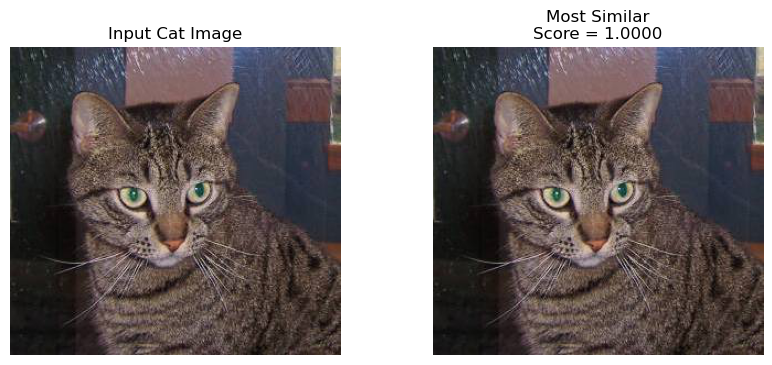

In [16]:
# ---------------------------------------------------
# 7. Display input and most similar image
# ---------------------------------------------------

input_img = Image.open(test_cat)
similar_img = Image.open(similar_image)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(input_img)
plt.title("Input Cat Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(similar_img)
plt.title(f"Most Similar\nScore = {score:.4f}")
plt.axis("off")

plt.show()

In [17]:

# ---------------------------------------------------
# 8. Test with DOG image
# ---------------------------------------------------

dog_images = glob.glob(os.path.join(image_folder, "dog*.jpg"))

test_dog = dog_images[0]

similar_dog_image, dog_score = find_most_similar(test_dog)

print("\nDOG TEST")
print("Input image:", test_dog)
print("Most similar stored cat:", similar_dog_image)
print("Similarity score:", round(dog_score, 4))



DOG TEST
Input image: images\dog_1.jpg
Most similar stored cat: images\cat_2.jpg
Similarity score: 0.2151


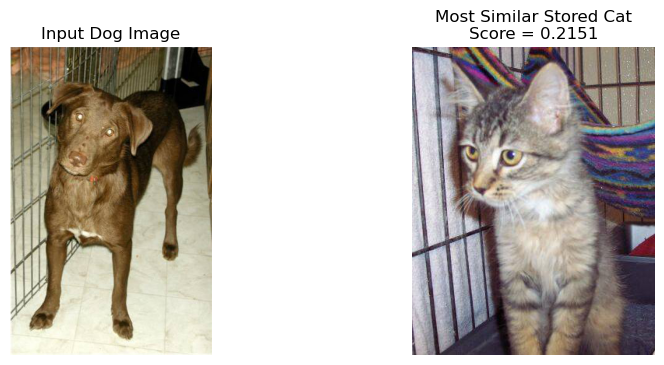

In [18]:
# ---------------------------------------------------
# 9. Display DOG vs stored CAT
# ---------------------------------------------------

dog_img = Image.open(test_dog)
similar_cat_img = Image.open(similar_dog_image)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(dog_img)
plt.title("Input Dog Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(similar_cat_img)
plt.title(f"Most Similar Stored Cat\nScore = {dog_score:.4f}")
plt.axis("off")

plt.show()

In [19]:
# ---------------------------------------------------
# 10. Compare results
# ---------------------------------------------------

print("\n========== FINAL RESULT ==========")

print("Cat similarity score :", round(score, 4))
print("Dog similarity score :", round(dog_score, 4))

if score > dog_score:
    print("\nThe CAT image is more similar to the stored CAT images.")
    print("The DOG image has lower similarity because it belongs to a different category.")
else:
    print("\nThe result may require more images or a different threshold.")


========== FINAL RESULT ==========
Cat similarity score : 1.0
Dog similarity score : 0.2151

The CAT image is more similar to the stored CAT images.
The DOG image has lower similarity because it belongs to a different category.
